# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated) with the canonical schema.
# Required column order:
# timestamp, commit, val_bpb, memory_gb, status, description
# timestamp is ISO-8601 (e.g. 2026-05-21T19:59:30-07:00).
df = pd.read_csv("results.tsv", sep="\t")
expected_cols = ["timestamp", "commit", "val_bpb", "memory_gb", "status", "description"]
if list(df.columns) != expected_cols:
    raise ValueError(f"results.tsv schema mismatch. Expected {expected_cols}, got {list(df.columns)}")

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="raise", utc=True)
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].astype(str).str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Time range (UTC): {df['timestamp'].min()} -> {df['timestamp'].max()}")
df.head(10)

Total experiments: 0
Columns: ['timestamp', 'commit', 'val_bpb', 'memory_gb', 'status', 'description']
Time range (UTC): NaT -> NaT


,timestamp,commit,val_bpb,memory_gb,status,description


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
Series([], )


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    ts = row["timestamp"]
    ts_text = ts.isoformat() if pd.notna(ts) else "n/a"
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  ts={ts_text}  {desc}")

KEPT experiments (0 total):



## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

KeyError: 0

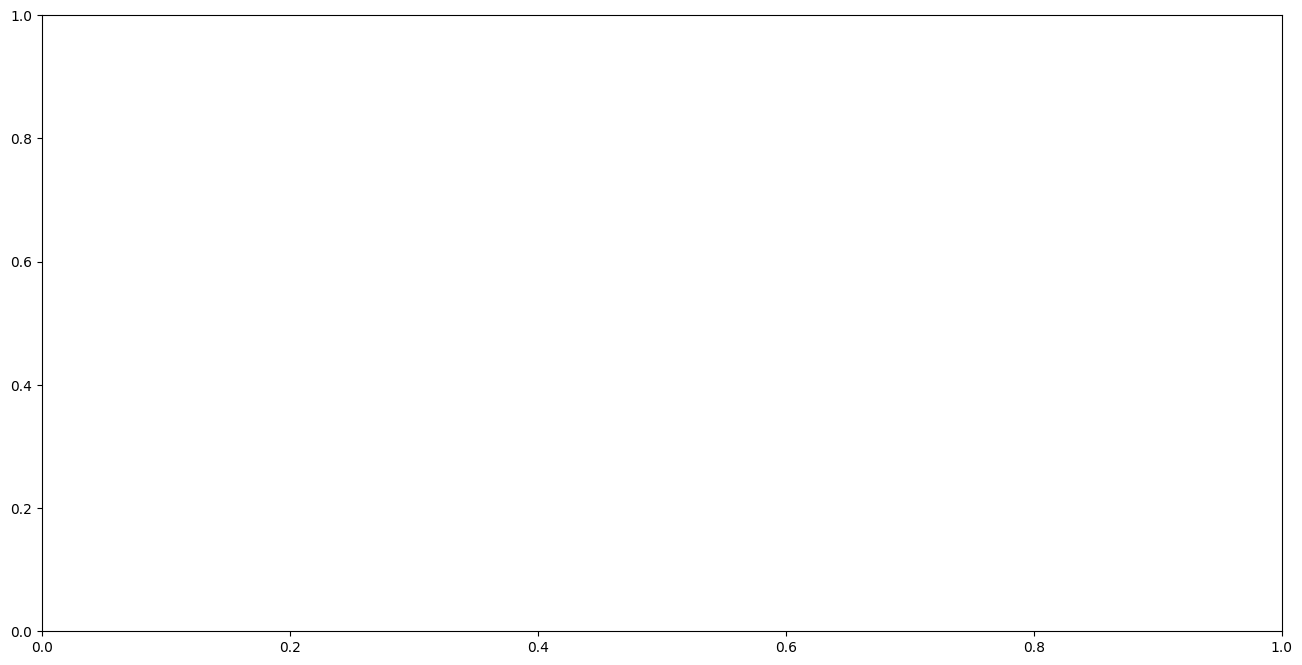

In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes and keep rows with valid timestamps for time-based plotting
valid = df[(df["status"] != "CRASH") & (df["timestamp"].notna())].copy()
valid = valid.sort_values("timestamp").reset_index(drop=True)
valid["exp_num"] = valid.index + 1

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005].copy()

# Plot discarded as larger faint dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(
    disc["timestamp"],
    disc["val_bpb"],
    c="#cccccc",
    s=220,
    alpha=0.55,
    zorder=2,
    label="Discarded",
    edgecolors="black",
    linewidths=0.5,
)

# Plot kept experiments as larger prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(
    kept_v["timestamp"],
    kept_v["val_bpb"],
    c="#2ecc71",
    s=320,
    zorder=4,
    label="Kept",
    edgecolors="black",
    linewidths=0.7,
)

# Put experiment number inside each dot
for _, row in below.iterrows():
    text_color = "black" if row["status"] == "DISCARD" else "white"
    ax.text(
        row["timestamp"],
        row["val_bpb"],
        f"{int(row['exp_num'])}",
        ha="center",
        va="center",
        fontsize=8,
        color=text_color,
        fontweight="bold",
        zorder=5,
    )

# Running minimum step line over kept experiments in time order
kept_mask = valid["status"] == "KEEP"
kept_t = valid.loc[kept_mask, "timestamp"]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(
    kept_t,
    running_min,
    where="post",
    color="#27ae60",
    linewidth=2,
    alpha=0.7,
    zorder=3,
    label="Running best",
)

# Label each kept experiment with its description
for _, row in valid[valid["status"] == "KEEP"].iterrows():
    desc = str(row["description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(
        desc,
        (row["timestamp"], row["val_bpb"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=8.0,
        color="#1a7a3a",
        alpha=0.9,
        rotation=25,
        ha="left",
        va="bottom",
    )

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Time (UTC)", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best = float(kept_bpb.min()) if len(kept_bpb) else float(baseline_bpb)
margin = max((baseline_bpb - best) * 0.15, 0.001)
ax.set_ylim(best - margin, baseline_bpb + margin)

fig.autofmt_xdate(rotation=25)
plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [ ]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  0.819446
Best val_bpb:      0.488583
Total improvement: 0.330863 (40.38%)
Best experiment:   total_batch_size 2^16->2^15: 1140 steps, very marginal gain

Cumulative effort per improvement:
  Experiment #  0: bpb=0.819446  baseline
  Experiment #  2: bpb=0.692907  depth 8->6: smaller model, 85 steps, faster tok/sec on laptop GPU
  Experiment #  4: bpb=0.662398  warmdown_ratio 0.5->0.2: 80% training at full LR vs 48%
  Experiment #  5: bpb=0.550738  total_batch_size 2^19->2^18: 158 steps vs 85, better muon ramp
  Experiment #  6: bpb=0.509055  total_batch_size 2^18->2^17: 302 steps, muon ramp completes
  Experiment #  7: bpb=0.490458  total_batch_size 2^17->2^16: 588 steps, diminishing returns
  Experiment #  8: bpb=0.490102  matrix_lr 0.04->0.05: marginal improvement
  Experiment #  9: bpb=0.488583  total_batch_size 2^16->2^15: 1140 steps, very marginal gain
  Experiment # 14: bpb=0.530646  baseline RTX 4000 Ada Laptop 12GB: 642 steps MQA+2^15
  Experiment # 22: bpb=0

## Top Hits (Kept Experiments by Improvement)

In [ ]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.126539  0.692907  depth 8->6: smaller model, 85 steps, faster tok/sec on laptop GPU
   2  +0.111660  0.550738  total_batch_size 2^19->2^18: 158 steps vs 85, better muon ramp
   3  +0.041683  0.509055  total_batch_size 2^18->2^17: 302 steps, muon ramp completes
   4  +0.030509  0.662398  warmdown_ratio 0.5->0.2: 80% training at full LR vs 48%
   5  +0.018597  0.490458  total_batch_size 2^17->2^16: 588 steps, diminishing returns
   6  +0.001519  0.488583  total_batch_size 2^16->2^15: 1140 steps, very marginal gain
   7  +0.000865  0.529781  muon warmup 300->150: matches Ada step budget, more steps at full momentum
   8  +0.000489  0.529292  muon warmup 150->100: marginal gain, more steps at full momentum
   9  +0.000356  0.490102  matrix_lr 0.04->0.05: marginal improvement
  10  +0.000000  0.529781  log: muon warmup 300->150 keep (0.529781 vs 0.530646)
  11  +